# FINANCIAL PERFORMANCE ANALYSIS -

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

###  DATA LOADING & INTEGRITY CHECKS

In [3]:
df_budget = pd.read_csv('Budget.csv')
df_customers = pd.read_csv('Customers.csv')
df_financial = pd.read_csv('Financial_Transactions.csv')
df_headcount = pd.read_csv('Headcount.csv')
df_vendors = pd.read_csv('Vendors.csv')

In [4]:
print(f"Dataset Shapes Loaded:")
print(f" - Budget:               {df_budget.shape}")
print(f" - Customers:            {df_customers.shape}")
print(f" - Financial Transactions: {df_financial.shape}")
print(f" - Headcount:            {df_headcount.shape}")
print(f" - Vendors:              {df_vendors.shape}\n")

Dataset Shapes Loaded:
 - Budget:               (72, 5)
 - Customers:            (400, 6)
 - Financial Transactions: (10400, 10)
 - Headcount:            (200, 7)
 - Vendors:              (120, 5)



In [5]:
# Primary Key Uniqueness Verification
print("Primary Key Uniqueness Check:")
print(f" - Customers Unique ID:  {df_customers['customer_id'].nunique() == len(df_customers)}")
print(f" - Vendors Unique ID:    {df_vendors['vendor_id'].nunique() == len(df_vendors)}")
print(f" - Headcount Unique ID:  {df_headcount['employee_id'].nunique() == len(df_headcount)}")
print(f" - Financial Unique ID:  {df_financial['transaction_id'].nunique() == len(df_financial)}")

Primary Key Uniqueness Check:
 - Customers Unique ID:  True
 - Vendors Unique ID:    True
 - Headcount Unique ID:  True
 - Financial Unique ID:  True


In [6]:
# Check duplicates and missing values
print(f"\nDuplicates in Financials: {df_financial.duplicated().sum()}")
print("Missing values in Financials:")
print(df_financial.isnull().sum()[df_financial.isnull().sum() > 0])


Duplicates in Financials: 0
Missing values in Financials:
customer_id    4886
vendor_id      6275
dtype: int64


### 2. DATA CLEANING & FEATURE ENGINEERING

In [8]:
df_financial['customer_id'] = df_financial['customer_id'].fillna('N/A')
df_financial['vendor_id'] = df_financial['vendor_id'].fillna('N/A')

In [9]:
# Date transformations
df_financial['transaction_date'] = pd.to_datetime(df_financial['transaction_date'])
df_financial['year'] = df_financial['transaction_date'].dt.year
df_financial['month'] = df_financial['transaction_date'].dt.month
df_financial['year_month'] = df_financial['transaction_date'].dt.to_period('M')


In [10]:
df_financial.head(3)

,transaction_id,transaction_date,amount,account_type,category,business_unit,region,customer_id,vendor_id,description,year,month,year_month
0,TRX100000,2023-09-03,-66631.73,Expense,Supplies,Online,West,N/A,VEND1053,Begin catch control dark practice.,2023,9,2023-09
1,TRX100001,2023-09-13,-54305.58,Expense,Utilities,Enterprise,East,N/A,VEND1059,Style guy soldier boy energy above.,2023,9,2023-09
2,TRX100002,2023-06-27,146074.92,Revenue,Subscription,Online,East,CUST10122,N/A,Skill surface drug personal western.,2023,6,2023-06


In [11]:
# Separate Revenue and Expense DataFrames
revenue = df_financial[df_financial['account_type'] == 'Revenue'].copy()
expense = df_financial[df_financial['account_type'] == 'Expense'].copy()
expense['amount_abs'] = expense['amount'].abs()

In [12]:
# Budget DataFrame
df_budget['year_month'] = pd.to_datetime(
    df_budget['year'].astype(str) + '-' + df_budget['month'].astype(str).str.zfill(2) + '-01'
).dt.to_period('M')

In [15]:
df_budget.head(3)

,year,month,business_unit,budgeted_revenue,budgeted_expense,year_month
0,2022,1,Retail,1530660,1259760,2022-01
1,2022,1,Enterprise,1689240,1152615,2022-01
2,2022,1,Online,2069088,1776169,2022-01


In [16]:
revenue.head(3)

,transaction_id,transaction_date,amount,account_type,category,business_unit,region,customer_id,vendor_id,description,year,month,year_month
2,TRX100002,2023-06-27,146074.92,Revenue,Subscription,Online,East,CUST10122,N/A,Skill surface drug personal western.,2023,6,2023-06
3,TRX100003,2023-06-25,212157.95,Revenue,Service,Enterprise,West,CUST10027,N/A,Develop many it I rich floor decide.,2023,6,2023-06
5,TRX100005,2023-03-04,90953.83,Revenue,Service,Retail,South,CUST10332,N/A,Dinner present unit lay course.,2023,3,2023-03


In [17]:
# Merge Actuals with Budget
actual_rev = revenue.groupby(['year', 'month', 'business_unit'])['amount'].sum().reset_index()
actual_rev.columns = ['year', 'month', 'business_unit', 'actual_revenue']

actual_exp = expense.groupby(['year', 'month', 'business_unit'])['amount_abs'].sum().reset_index()
actual_exp.columns = ['year', 'month', 'business_unit', 'actual_expense']

merged_budget = df_budget.merge(actual_rev, on=['year', 'month', 'business_unit'], how='left')
merged_budget = merged_budget.merge(actual_exp, on=['year', 'month', 'business_unit'], how='left').fillna(0)

In [18]:
actual_rev.head(3)

,year,month,business_unit,actual_revenue
0,2022,1,Enterprise,9000016.39
1,2022,1,Online,9222358.75
2,2022,1,Retail,7315722.74


In [19]:
actual_exp.head(3)

,year,month,business_unit,actual_expense
0,2022,1,Enterprise,2257337.53
1,2022,1,Online,2836633.16
2,2022,1,Retail,2305293.23


In [20]:
merged_budget.head(3)

,year,month,business_unit,budgeted_revenue,budgeted_expense,year_month,actual_revenue,actual_expense
0,2022,1,Retail,1530660,1259760,2022-01,7315722.74,2305293.23
1,2022,1,Enterprise,1689240,1152615,2022-01,9000016.39,2257337.53
2,2022,1,Online,2069088,1776169,2022-01,9222358.75,2836633.16


In [21]:
# Variance Calculations
merged_budget['budgeted_profit'] = merged_budget['budgeted_revenue'] - merged_budget['budgeted_expense']
merged_budget['actual_profit'] = merged_budget['actual_revenue'] - merged_budget['actual_expense']
merged_budget['revenue_variance'] = merged_budget['actual_revenue'] - merged_budget['budgeted_revenue']
merged_budget['expense_variance'] = merged_budget['actual_expense'] - merged_budget['budgeted_expense']
merged_budget['profit_variance'] = merged_budget['actual_profit'] - merged_budget['budgeted_profit']


In [22]:
merged_budget.head(3)

,year,month,business_unit,budgeted_revenue,budgeted_expense,year_month,actual_revenue,actual_expense,budgeted_profit,actual_profit,revenue_variance,expense_variance,profit_variance
0,2022,1,Retail,1530660,1259760,2022-01,7315722.74,2305293.23,270900,5010429.51,5785062.74,1045533.23,4739529.51
1,2022,1,Enterprise,1689240,1152615,2022-01,9000016.39,2257337.53,536625,6742678.86,7310776.39,1104722.53,6206053.86
2,2022,1,Online,2069088,1776169,2022-01,9222358.75,2836633.16,292919,6385725.59,7153270.75,1060464.16,6092806.59


## SUMMARY STATISTICS & OUTLIER DETECTION 

In [27]:
# currency formats values into clean $M or $K def

def format_currency(value):
    if abs(value) >= 1000000:
        return f"${value / 1000000:.2f}M"
    elif abs(value) >= 1000:
        return f"${value / 1000:.1f}K"
    else:
        return f"${value:.2f}"

In [29]:

def summary_stats(series, name):
    mean_val = series.mean()
    std_val = series.std()
    median_val = series.median()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr_val = q3 - q1
    lower_bound = q1 - 1.5 * iqr_val
    upper_bound = q3 + 1.5 * iqr_val
    outliers = series[(series < lower_bound) | (series > upper_bound)].count()
    
    print(f"\n--- {name} Summary Statistics ---")
    print(f"Count:        {series.count()}")
    print(f"Mean:         {format_currency(mean_val)}")
    print(f"Std Dev:      {format_currency(std_val)}")
    print(f"Median:       {format_currency(median_val)}")
    print(f"IQR:          {format_currency(iqr_val)}")
    print(f"Min / Max:    {format_currency(series.min())} / {format_currency(series.max())}")
    print(f"Outliers (1.5*IQR): {outliers} ({outliers/len(series)*100:.2f}%)")


In [30]:
summary_stats(revenue['amount'], "Revenue Transaction Amount")
summary_stats(expense['amount'], "Expense Transaction Amount")


--- Revenue Transaction Amount Summary Statistics ---
Count:        5514
Mean:         $156.8K
Std Dev:      $52.0K
Median:       $153.9K
IQR:          $69.0K
Min / Max:    $5.0K / $351.4K
Outliers (1.5*IQR): 51 (0.92%)

--- Expense Transaction Amount Summary Statistics ---
Count:        4125
Mean:         $-40.7K
Std Dev:      $19.2K
Median:       $-40.5K
IQR:          $26.5K
Min / Max:    $-113.3K / $-2.0K
Outliers (1.5*IQR): 14 (0.34%)


In [31]:
revenue['amount'].describe()

count      5514.000000
mean     156802.428763
std       51989.980218
min        5000.000000
25%      121379.810000
50%      153910.430000
75%      190384.737500
max      351386.850000
Name: amount, dtype: float64

In [33]:
expense['amount'].describe()

count      4125.000000
mean     -40664.557527
std       19232.926149
min     -113310.710000
25%      -53648.500000
50%      -40510.710000
75%      -27137.340000
max       -2000.000000
Name: amount, dtype: float64

## FINANCIAL KPI & BUDGET VARIANCE         
## Overview
We aggregate transaction performance across all 24 months (2022–2023) and compare actual financial execution against planned budget allocations by Business Unit.

In [34]:
total_act_rev = merged_budget['actual_revenue'].sum()
total_bud_rev = merged_budget['budgeted_revenue'].sum()
total_act_exp = merged_budget['actual_expense'].sum()
total_bud_exp = merged_budget['budgeted_expense'].sum()
total_act_prof = merged_budget['actual_profit'].sum()
total_bud_prof = merged_budget['budgeted_profit'].sum()

print(f"Total Actual Revenue:   {format_currency(total_act_rev)} (Budget: {format_currency(total_bud_rev)}, Var: {format_currency(total_act_rev - total_bud_rev)})")
print(f"Total Actual Expenses:  {format_currency(total_act_exp)} (Budget: {format_currency(total_bud_exp)}, Var: {format_currency(total_act_exp - total_bud_exp)})")
print(f"Total Net Profit:       {format_currency(total_act_prof)} (Budget: {format_currency(total_bud_prof)}, Var: {format_currency(total_act_prof - total_bud_prof)})")


Total Actual Revenue:   $864.61M (Budget: $135.81M, Var: $728.79M)
Total Actual Expenses:  $167.74M (Budget: $104.27M, Var: $63.48M)
Total Net Profit:       $696.87M (Budget: $31.55M, Var: $665.32M)


In [36]:
print("\nPerformance by Business Unit:")
bu_perf = merged_budget.groupby('business_unit').agg(
    actual_revenue=('actual_revenue', 'sum'),
    budgeted_revenue=('budgeted_revenue', 'sum'),
    revenue_variance=('revenue_variance', 'sum'),
    actual_expense=('actual_expense', 'sum'),
    budgeted_expense=('budgeted_expense', 'sum'),
    expense_variance=('expense_variance', 'sum'),
    actual_profit=('actual_profit', 'sum')
)
bu_perf.map(format_currency)



Performance by Business Unit:


,actual_revenue,budgeted_revenue,revenue_variance,actual_expense,budgeted_expense,expense_variance,actual_profit
business_unit,,,,,,,
Enterprise,$281.40M,$44.68M,$236.72M,$57.02M,$33.59M,$23.43M,$224.37M
Online,$297.53M,$47.30M,$250.23M,$55.30M,$37.13M,$18.17M,$242.23M
Retail,$285.68M,$43.83M,$241.85M,$55.42M,$33.54M,$21.87M,$230.26M


In [37]:
print("\nPerformance by Business Unit:")
category_monthly = revenue.groupby(['year', 'month', 'category'])['amount'].sum()

category_monthly.map(format_currency)


Performance by Business Unit:


year  month  category    
2022  1      Product          $8.06M
             Service          $7.80M
             Subscription     $9.67M
      2      Product          $7.24M
             Service          $8.01M
                              ...   
2023  11     Service         $15.57M
             Subscription    $15.63M
      12     Product         $17.02M
             Service         $17.45M
             Subscription    $18.26M
Name: amount, Length: 72, dtype: object

In [40]:
cat_perf = revenue.groupby('category')['amount'].sum()
cat_perf.map(format_currency)

category
Product         $284.12M
Service         $288.63M
Subscription    $291.85M
Name: amount, dtype: object

## STATISTICAL HYPOTHESIS TESTING

In [41]:
monthly_exp = expense.groupby(['year', 'month', 'business_unit'])['amount_abs'].sum().reset_index()
online_exp = monthly_exp[monthly_exp['business_unit']=='Online']['amount_abs']
retail_exp = monthly_exp[monthly_exp['business_unit']=='Retail']['amount_abs']
enterprise_exp = monthly_exp[monthly_exp['business_unit']=='Enterprise']['amount_abs']

f_stat, p_val = stats.f_oneway(online_exp, retail_exp, enterprise_exp)
print(f"\nANOVA: F = {f_stat:.3f}, p = {p_val:.4f}")
if p_val < 0.5:
    print("Conclusion: There is significant difference in monthly expenses across units.")
else:
        print("Conclusion: No significant difference in monthly expenses across units.")


ANOVA: F = 0.368, p = 0.6932
Conclusion: No significant difference in monthly expenses across units.


In [42]:
# 2. ANOVA: Revenue per transaction across Revenue Categories
cat_rev_groups = [group['amount'].values for name, group in revenue.groupby('category')]
f_stat_cat, p_val_cat = stats.f_oneway(*cat_rev_groups)
print(f"\n2. ANOVA (Revenue Transaction Size across Revenue Categories):")
print(f"   F-Statistic = {f_stat_cat:.4f}, p-value = {p_val_cat:.4f}")
print(f"   Interpretation: {'Statistically significant' if p_val_cat < 0.05 else 'Homogeneous transaction amounts across Subscription, Service, and Product'}")



2. ANOVA (Revenue Transaction Size across Revenue Categories):
   F-Statistic = 0.8803, p-value = 0.4147
   Interpretation: Homogeneous transaction amounts across Subscription, Service, and Product


In [44]:
# 3. Two-Sample Independent T-Test: Revenue in North vs. South Region
north_rev = revenue[revenue['region'] == 'North']['amount']
south_rev = revenue[revenue['region'] == 'South']['amount']
t_stat, p_val_ttest = stats.ttest_ind(north_rev, south_rev)
print(f"\n3. Two-Sample T-Test (Revenue Transaction Size: North vs. South Region):")
print(f"   T-Statistic = {t_stat:.4f}, p-value = {p_val_ttest:.4f}")
print(f"   Interpretation: {'Statistically significant difference' if p_val_ttest < 0.05 else 'No significant difference between North and South average transaction size'}")



3. Two-Sample T-Test (Revenue Transaction Size: North vs. South Region):
   T-Statistic = 0.0285, p-value = 0.9772
   Interpretation: No significant difference between North and South average transaction size


In [45]:
# 3a. Two-Sample Independent T-Test: Revenue in East vs. West Region
East_rev = revenue[revenue['region'] == 'East']['amount']
West_rev = revenue[revenue['region'] == 'West']['amount']
t_stat, p_val_ttest = stats.ttest_ind(East_rev, West_rev)
print(f"\n3. Two-Sample T-Test (Revenue Transaction Size: East vs. West Region):")
print(f"   T-Statistic = {t_stat:.4f}, p-value = {p_val_ttest:.4f}")
print(f"   Interpretation: {'Statistically significant difference' if p_val_ttest < 0.05 else 'No significant difference between East and West average transaction size'}")



3. Two-Sample T-Test (Revenue Transaction Size: East vs. West Region):
   T-Statistic = 0.7460, p-value = 0.4557
   Interpretation: No significant difference between East and West average transaction size


In [46]:
# 4. Chi-Square Test: Customer Segment vs Business Unit
rev_cust_merged = revenue.merge(df_customers, on='customer_id', how='left')
contingency = pd.crosstab(rev_cust_merged['segment'], rev_cust_merged['business_unit'])
chi2_stat, p_val_chi2, dof, _ = stats.chi2_contingency(contingency)
print(f"\n4. Chi-Square Test of Independence (Customer Segment vs Business Unit):")
print(f"   Chi2 Statistic = {chi2_stat:.4f}, p-value = {p_val_chi2:.4f}, degrees of freedom = {dof}")
print(f"   Interpretation: {'Associated' if p_val_chi2 < 0.05 else 'Customer segments are independently distributed across Business Units'}")



4. Chi-Square Test of Independence (Customer Segment vs Business Unit):
   Chi2 Statistic = 2.6566, p-value = 0.6168, degrees of freedom = 4
   Interpretation: Customer segments are independently distributed across Business Units


In [56]:

# Let's test Employee CTC across Business Units (ANOVA)
bu_ctc_groups = [group['cost_to_company'].values for name, group in df_headcount.groupby('business_unit')]
f_ctc_bu, p_ctc_bu = stats.f_oneway(*bu_ctc_groups)

# Let's test Employee CTC across Regions (ANOVA)
reg_ctc_groups = [group['cost_to_company'].values for name, group in df_headcount.groupby('region')]
f_ctc_reg, p_ctc_reg = stats.f_oneway(*reg_ctc_groups)

# Let's calculate 95% Confidence Intervals for Cost per Employee by BU
def mean_confidence_interval(data, confidence=0.95):
    a = 1.0 * np.array(data)
    n = len(a)
    m, se = np.mean(a), stats.sem(a)
    h = se * stats.t.ppf((1 + confidence) / 2., n-1)
    return m, m-h, m+h

print("=== HYPOTHESIS TEST: CTC ACROSS BUSINESS UNITS ===")
print(f"F-stat = {f_ctc_bu:.4f}, p-value = {p_ctc_bu:.4f}")
for bu, group in df_headcount.groupby('business_unit'):
    m, l, u = mean_confidence_interval(group['cost_to_company'])
    print(f" - {bu}: Mean CTC = ${format_currency(m)} [95% CI: ${format_currency(l)} - ${format_currency(u)}]")

print("\n=== HYPOTHESIS TEST: CTC ACROSS REGIONS ===")
print(f"F-stat = {f_ctc_reg:.4f}, p-value = {p_ctc_reg:.4f}")
for reg, group in df_headcount.groupby('region'):
    m, l, u = mean_confidence_interval(group['cost_to_company'])
    print(f" - {reg}: Mean CTC = ${format_currency(m)} [95% CI: ${format_currency(l)} - ${format_currency(u)}]")

# Customer Metrics Summary
cust_summary = revenue.groupby('customer_id')['amount'].agg(['sum', 'mean', 'count'])
print("\n=== REVENUE PER CUSTOMER STATS ===")
print(f"Total Unique Customers with Transactions: {cust_summary.index.nunique()}")
print(f"Mean Total Revenue per Customer: ${format_currency(cust_summary['sum'].mean())}")
print(f"Median Total Revenue per Customer: ${format_currency(cust_summary['sum'].median())}")

# Vendor Metrics Summary
vend_summary = expense.groupby('vendor_id')['amount_abs'].agg(['sum', 'mean', 'count'])
print("\n=== EXPENSE PER VENDOR STATS ===")
print(f"Total Unique Vendors with Transactions: {vend_summary.index.nunique()}")
print(f"Mean Total Expense per Vendor: ${format_currency(vend_summary['sum'].mean())}")
print(f"Median Total Expense per Vendor: ${format_currency(vend_summary['sum'].median())}")

=== HYPOTHESIS TEST: CTC ACROSS BUSINESS UNITS ===
F-stat = 0.3643, p-value = 0.6952
 - Enterprise: Mean CTC = $$1.15M [95% CI: $$1.04M - $$1.25M]
 - Online: Mean CTC = $$1.09M [95% CI: $$993.0K - $$1.19M]
 - Retail: Mean CTC = $$1.11M [95% CI: $$1.02M - $$1.20M]

=== HYPOTHESIS TEST: CTC ACROSS REGIONS ===
F-stat = 0.3544, p-value = 0.7860
 - East: Mean CTC = $$1.15M [95% CI: $$1.04M - $$1.25M]
 - North: Mean CTC = $$1.12M [95% CI: $$1.01M - $$1.23M]
 - South: Mean CTC = $$1.06M [95% CI: $$948.3K - $$1.18M]
 - West: Mean CTC = $$1.12M [95% CI: $$987.6K - $$1.24M]

=== REVENUE PER CUSTOMER STATS ===
Total Unique Customers with Transactions: 372
Mean Total Revenue per Customer: $$2.32M
Median Total Revenue per Customer: $$2.30M

=== EXPENSE PER VENDOR STATS ===
Total Unique Vendors with Transactions: 120
Mean Total Expense per Vendor: $$1.40M
Median Total Expense per Vendor: $$1.54M


In [74]:
print("=== HEADCOUNT & COST PER EMPLOYEE ===")
hc_bu = df_headcount.groupby('business_unit').agg(
    total_employees=('employee_id', 'count'),
    active_employees=('status', lambda x: (x == 'Active').sum()),
    total_ctc=('cost_to_company', 'sum'),
    avg_ctc=('cost_to_company', 'mean')
).reset_index()

# Convert to Millions and format
hc_bu['total_ctc'] = hc_bu['total_ctc'].map(format_currency)
hc_bu['avg_ctc'] = hc_bu['avg_ctc'].map(format_currency)

hc_bu

=== HEADCOUNT & COST PER EMPLOYEE ===


,business_unit,total_employees,active_employees,total_ctc,avg_ctc
0,Enterprise,59,57,$67.80M,$1.15M
1,Online,75,68,$81.74M,$1.09M
2,Retail,66,61,$73.29M,$1.11M


In [101]:
print("\n=== HEADCOUNT & COST PER EMPLOYEE BY REGION ===")
hc_region = df_headcount.groupby('region').agg(
    total_employees=('employee_id', 'count'),
    active_employees=('status', lambda x: (x == 'Active').sum()),
    total_ctc=('cost_to_company', 'sum'),
    avg_ctc=('cost_to_company', 'mean')
).reset_index()

hc_region['total_ctc'] = hc_region['total_ctc'].map(format_currency)
hc_region['avg_ctc'] = hc_region['avg_ctc'].map(format_currency)
hc_region



=== HEADCOUNT & COST PER EMPLOYEE BY REGION ===


,region,total_employees,active_employees,total_ctc,avg_ctc
0,East,50,44,$57.42M,$1.15M
1,North,60,58,$67.25M,$1.12M
2,South,43,42,$45.73M,$1.06M
3,West,47,42,$52.43M,$1.12M


In [102]:
# 3. Revenue per Customer Aggregations
df_financial['transaction_date'] = pd.to_datetime(df_financial['transaction_date'])
revenue = df_financial[df_financial['account_type'] == 'Revenue'].copy()
expense = df_financial[df_financial['account_type'] == 'Expense'].copy()
expense['amount_abs'] = expense['amount'].abs()

In [104]:
rev_customer = revenue.groupby('customer_id')['amount'].agg(
    total_revenue='sum',
    avg_revenue='mean',
    transaction_count='count'
).reset_index()
rev_customer = rev_customer.merge(df_customers, on='customer_id', how='left')

# 4. Expense per Vendor Aggregations
exp_vendor = expense.groupby('vendor_id')['amount_abs'].agg(
    total_expense='sum',
    avg_expense='mean',
    transaction_count='count'
).reset_index()
exp_vendor = exp_vendor.merge(df_vendors, on='vendor_id', how='left')

In [107]:
# Print Top 10 Customers
print("\nTop 10 Customers by Total Revenue:")
top_cust = rev_customer.sort_values(by='total_revenue', ascending=False).head(10).copy()
top_cust['total_revenue'] = top_cust['total_revenue'].apply(format_currency)
top_cust['avg_revenue'] = top_cust['avg_revenue'].apply(format_currency)
print(top_cust[['customer_id', 'customer_name', 'segment', 'region', 'total_revenue', 'avg_revenue', 'transaction_count']].to_string(index=False))



Top 10 Customers by Total Revenue:
customer_id                customer_name    segment region total_revenue avg_revenue  transaction_count
  CUST10043  Gonzalez, Barton and Robles     Retail   East        $4.24M     $151.3K                 28
  CUST10307                 Anderson LLC     Retail  North        $4.22M     $175.9K                 24
  CUST10237 Snow, Campbell and Dominguez     Online  North        $4.04M     $155.5K                 26
  CUST10072               Sullivan Group Enterprise  South        $3.81M     $173.2K                 22
  CUST10353                Santiago-Gray     Retail   West        $3.79M     $164.9K                 23
  CUST10061               Davis-Gonzales Enterprise  South        $3.77M     $163.8K                 23
  CUST10228              Newton and Sons     Retail  South        $3.72M     $161.8K                 23
  CUST10052                 Obrien-Allen Enterprise   West        $3.65M     $158.9K                 23
  CUST10049  Sullivan, Leon 

In [108]:
# Print Top 10 Vendors
print("\nTop 10 Vendors by Total Expense:")
top_vend = exp_vendor.sort_values(by='total_expense', ascending=False).head(10).copy()
top_vend['total_expense'] = top_vend['total_expense'].apply(format_currency)
top_vend['avg_expense'] = top_vend['avg_expense'].apply(format_currency)
print(top_vend[['vendor_id', 'vendor_name', 'category', 'region', 'total_expense', 'avg_expense', 'transaction_count']].to_string(index=False))


Top 10 Vendors by Total Expense:
vendor_id                  vendor_name  category region total_expense avg_expense  transaction_count
 VEND1095  Crawford, Solis and Jackson  Supplies  South        $2.83M      $44.9K                 63
 VEND1065                   Walker Inc  Supplies   East        $2.77M      $42.6K                 65
 VEND1018   Dorsey, Barrera and Parker Utilities   East        $2.73M      $44.8K                 61
 VEND1117       Boyd, Lozano and Gomez Utilities   East        $2.68M      $44.6K                 60
 VEND1032     Horne, Taylor and Watson  Supplies  North        $2.47M      $46.7K                 53
 VEND1059  Dominguez, King and Kaufman Utilities  South        $2.46M      $44.0K                 56
 VEND1078             Alexander-Arnold Utilities  North        $2.45M      $48.0K                 51
 VEND1100               Quinn and Sons  Supplies   West        $2.44M      $42.8K                 57
 VEND1112 Harmon, Torres and Mccormick  Supplies   West  

In [109]:
# Monthly overall trend
monthly_trend = merged_budget.groupby('year_month').agg({
    'budgeted_revenue': 'sum',
    'actual_revenue': 'sum',
    'budgeted_expense': 'sum',
    'actual_expense': 'sum',
    'actual_profit': 'sum'
}).reset_index()

monthly_trend['year_month_str'] = monthly_trend['year_month'].astype(str)
monthly_trend['cum_actual_rev'] = monthly_trend['actual_revenue'].cumsum()
monthly_trend['cum_budget_rev'] = monthly_trend['budgeted_revenue'].cumsum()

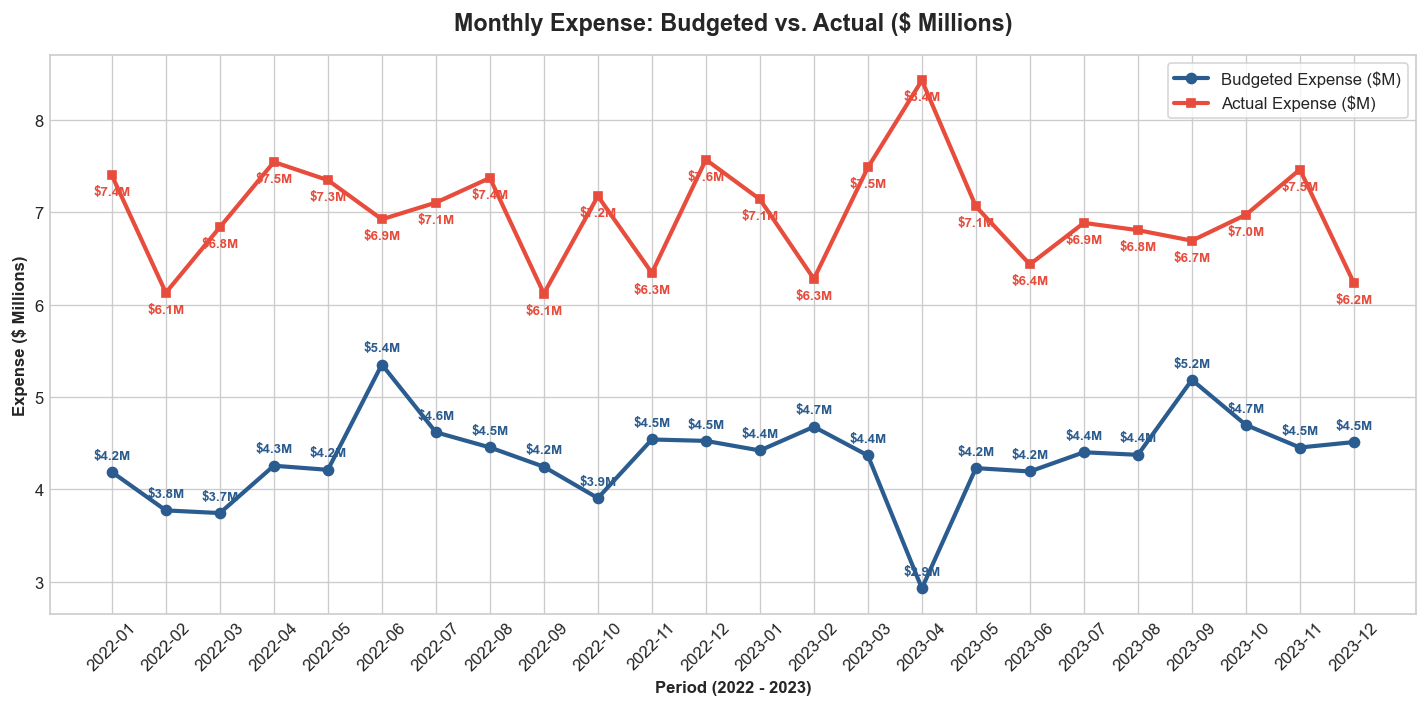

In [157]:


# Chart 2: Monthly Expense Trend (Budget vs Actual)
plt.figure(figsize=(12, 6))

# Plot lines
plt.plot(monthly_trend['year_month_str'], monthly_trend['budgeted_expense']/1e6, marker='o', label='Budgeted Expense ($M)', color='#2b5c8f', linewidth=2.5)
plt.plot(monthly_trend['year_month_str'], monthly_trend['actual_expense']/1e6, marker='s',markersize = 5,  label='Actual Expense ($M)', color='#e74c3c', linewidth=2.5)

# --- Add Data Labels ---

# Labels for Budgeted Expense (placed slightly above the markers)
for x, y in zip(monthly_trend['year_month_str'], monthly_trend['budgeted_expense']/1e6):
    plt.annotate(f'${y:.1f}M', 
                 (x, y), 
                 textcoords="offset points", 
                 xytext=(0, 8),          # 8 points vertical offset above
                 ha='center', 
                 fontsize=8, 
                 fontweight='bold', 
                 color='#2b5c8f')

# Labels for Actual Expense (placed slightly below the markers)
for x, y in zip(monthly_trend['year_month_str'], monthly_trend['actual_expense']/1e6):
    plt.annotate(f'${y:.1f}M', 
                 (x, y), 
                 textcoords="offset points", 
                 xytext=(0, -12),        # 12 points vertical offset below
                 ha='center', 
                 fontsize=8, 
                 fontweight='bold', 
                 color='#e74c3c')

# --- Formatting ---
plt.title('Monthly Expense: Budgeted vs. Actual ($ Millions)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Period (2022 - 2023)', fontweight='bold')
plt.ylabel('Expense ($ Millions)', fontweight='bold')
plt.xticks(rotation=45)
plt.legend(frameon=True, facecolor='white')


plt.tight_layout()
plt.savefig('chart2_expense_trend.png')
plt.show()

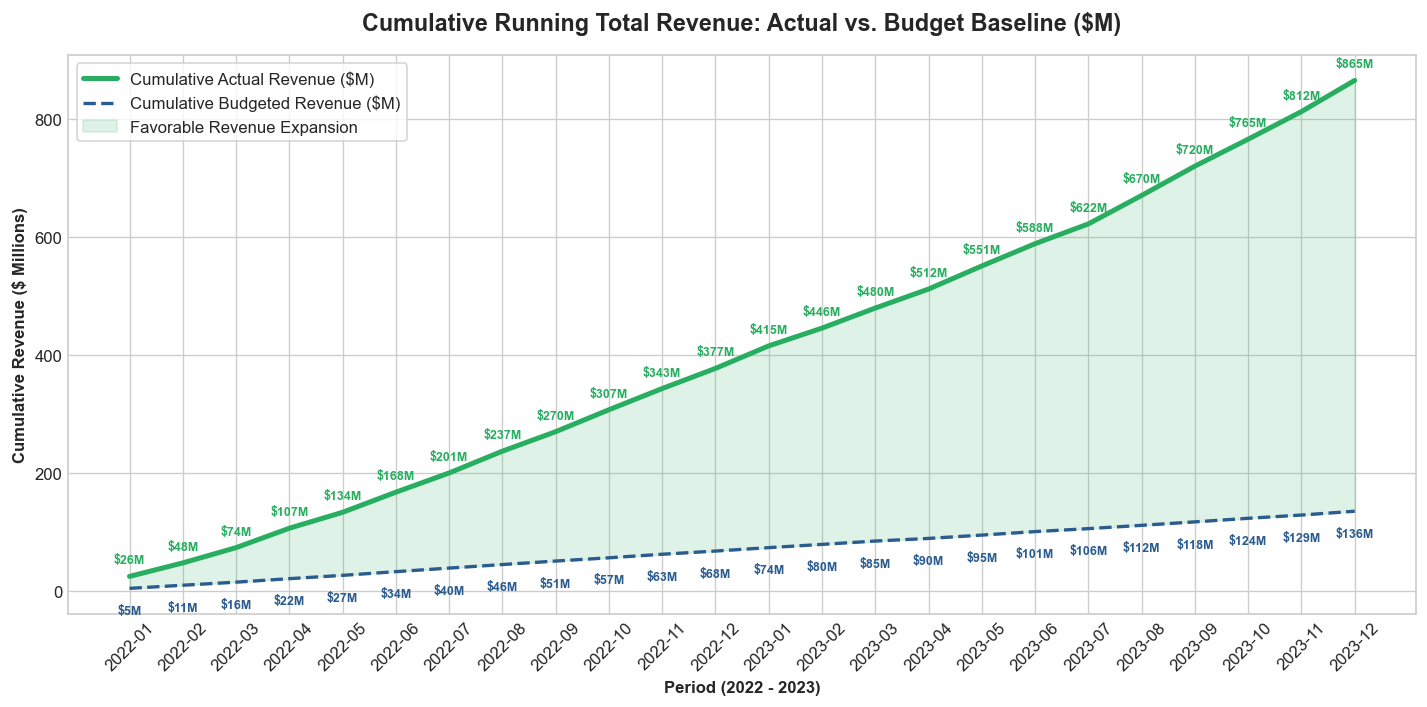

In [123]:


# Chart 3: Cumulative Running Total Revenue
plt.figure(figsize=(12, 6))

x_vals = monthly_trend['year_month_str']
actual_cum = monthly_trend['cum_actual_rev'] / 1e6
budget_cum = monthly_trend['cum_budget_rev'] / 1e6

# Plot lines and fill
plt.plot(x_vals, actual_cum, label='Cumulative Actual Revenue ($M)', color='#27ae60', linewidth=3)
plt.plot(x_vals, budget_cum, label='Cumulative Budgeted Revenue ($M)', color='#2b5c8f', linewidth=2, linestyle='--')
plt.fill_between(x_vals, budget_cum, actual_cum, color='#27ae60', alpha=0.15, label='Favorable Revenue Expansion')

# --- ADDED DATA LABELS ---

# 1. Labels for Actual Cumulative Revenue (Placed slightly ABOVE)
for x, y in zip(x_vals, actual_cum):
    plt.annotate(f"${y:.0f}M",              # Use format_currency(y) if preferred
                 xy=(x, y), 
                 textcoords="offset points", 
                 xytext=(0, 6),             # 6 points above
                 ha='center', va='bottom', 
                 fontsize=7.5, fontweight='bold', color='#27ae60')

# 2. Labels for Budgeted Cumulative Revenue (Placed slightly BELOW)
for x, y in zip(x_vals, budget_cum):
    plt.annotate(f"${y:.0f}M", 
                 xy=(x, y), 
                 textcoords="offset points", 
                 xytext=(0, -10),           # 10 points below
                 ha='center', va='top', 
                 fontsize=7.5, fontweight='bold', color='#2b5c8f')

# --- Formatting ---
plt.title('Cumulative Running Total Revenue: Actual vs. Budget Baseline ($M)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Period (2022 - 2023)', fontweight='bold')
plt.ylabel('Cumulative Revenue ($ Millions)', fontweight='bold')
plt.xticks(rotation=45)
plt.legend(frameon=True, facecolor='white', loc='upper left')



plt.tight_layout()
plt.savefig('chart3_cumulative_revenue.png')
plt.show()

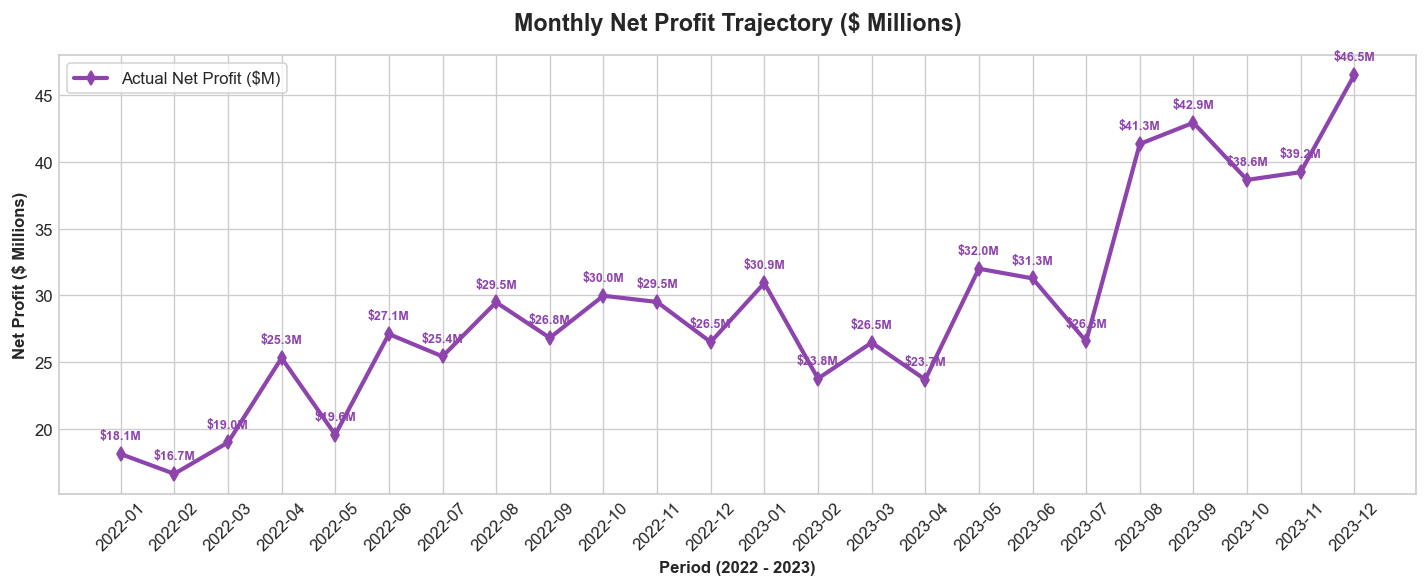

In [125]:

# Chart 4: Monthly Net Profit Trajectory
plt.figure(figsize=(12, 5))

x_vals = monthly_trend['year_month_str']
profit_vals = monthly_trend['actual_profit'] / 1e6

# Plot line
plt.plot(x_vals, profit_vals, marker='d', label='Actual Net Profit ($M)', color='#8e44ad', linewidth=2.5)

# --- ADDED DATA LABELS ---
for x, y in zip(x_vals, profit_vals):
    plt.annotate(f"${y:.1f}M",              # Use format_currency(y) if preferred
                 xy=(x, y), 
                 textcoords="offset points", 
                 xytext=(0, 7),             # 7 points vertical offset above marker
                 ha='center', va='bottom', 
                 fontsize=7.5, fontweight='bold', color='#8e44ad')

# Formatting
plt.title('Monthly Net Profit Trajectory ($ Millions)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Period (2022 - 2023)', fontweight='bold')
plt.ylabel('Net Profit ($ Millions)', fontweight='bold')
plt.xticks(rotation=45)
plt.legend(frameon=True, facecolor='white')

plt.tight_layout()
plt.savefig('chart4_profit_trajectory.png')
plt.show()

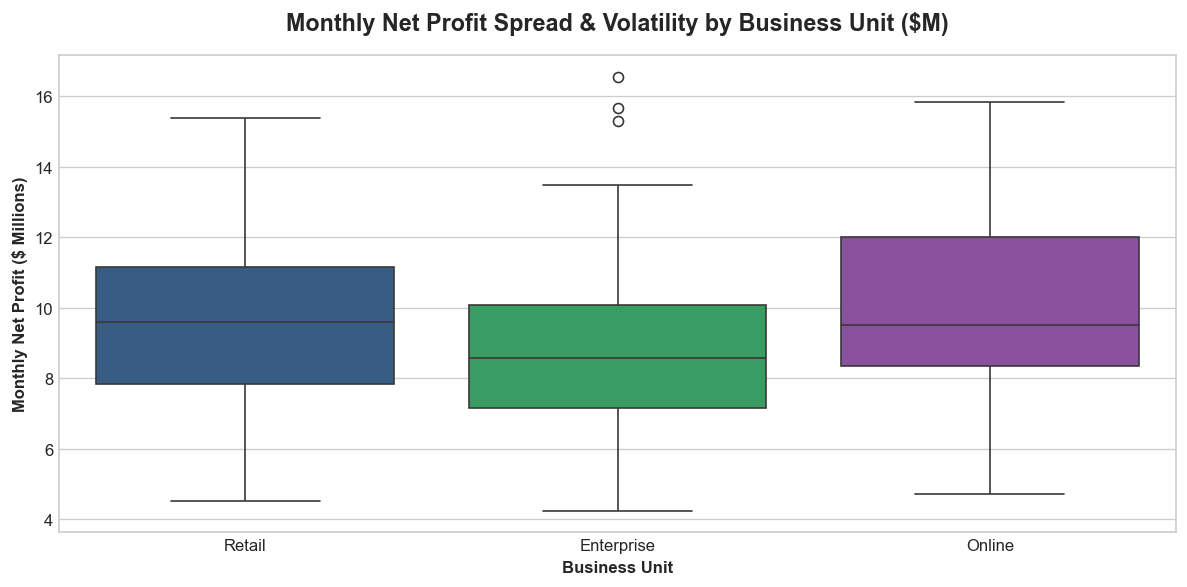

In [127]:

# Profit Spread & Volatility by Business Unit (Boxplot)

plt.figure(figsize=(10, 5))
sns.boxplot(
    x="business_unit",
    y=merged_budget["actual_profit"] / 1e6,
    data=merged_budget,
    hue="business_unit",  # <--- FIXED: Assign x variable to hue
    palette=["#2b5c8f", "#27ae60", "#8e44ad"],
    legend=False,  # <--- FIXED: Turn off redundant legend
)

plt.title(
    "Monthly Net Profit Spread & Volatility by Business Unit ($M)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Business Unit", fontweight="bold")
plt.ylabel("Monthly Net Profit ($ Millions)", fontweight="bold")
plt.tight_layout()
plt.savefig("chart10_profit_volatility_boxplot.png")
plt.show()

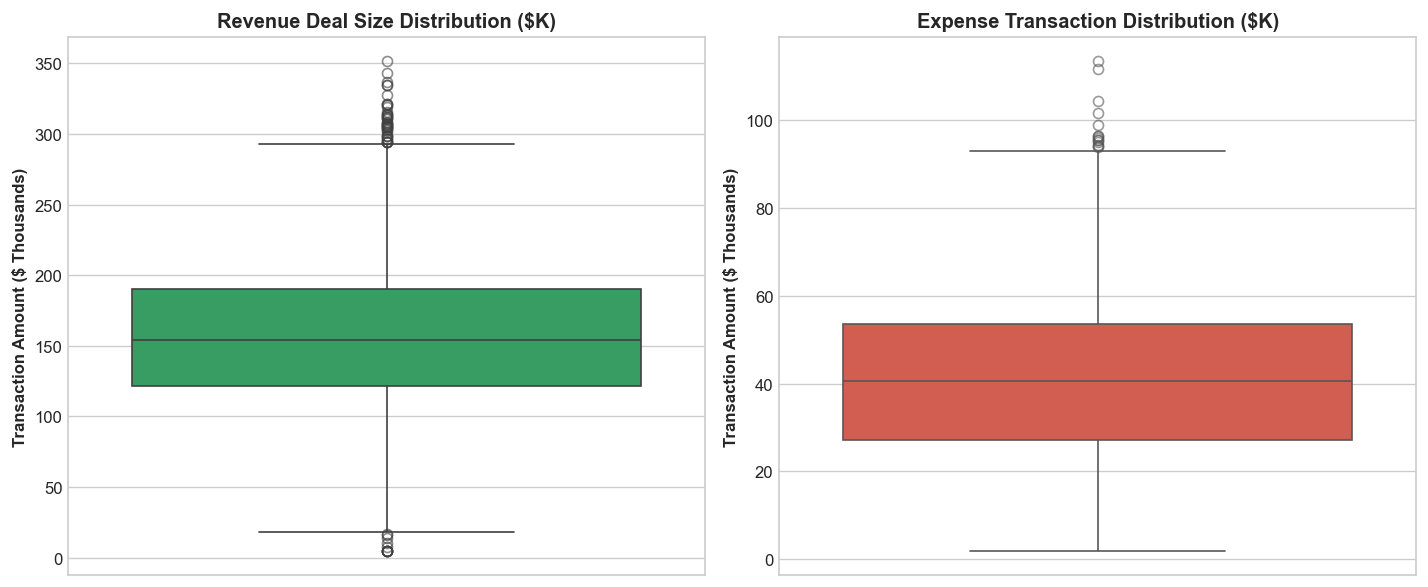

In [128]:
# Transaction Size Distributions & Outliers (Boxplots)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(
    y=revenue["amount"] / 1e3,
    ax=axes[0],
    color="#27ae60",
    flierprops=dict(marker="o", color="#27ae60", alpha=0.6),
)
axes[0].set_title("Revenue Deal Size Distribution ($K)", fontweight="bold")
axes[0].set_ylabel("Transaction Amount ($ Thousands)", fontweight="bold")

sns.boxplot(
    y=expense["amount_abs"] / 1e3,
    ax=axes[1],
    color="#e74c3c",
    flierprops=dict(marker="o", color="#e74c3c", alpha=0.6),
)
axes[1].set_title("Expense Transaction Distribution ($K)", fontweight="bold")
axes[1].set_ylabel("Transaction Amount ($ Thousands)", fontweight="bold")

plt.tight_layout()
plt.savefig("chart9_boxplots.png")
plt.show()

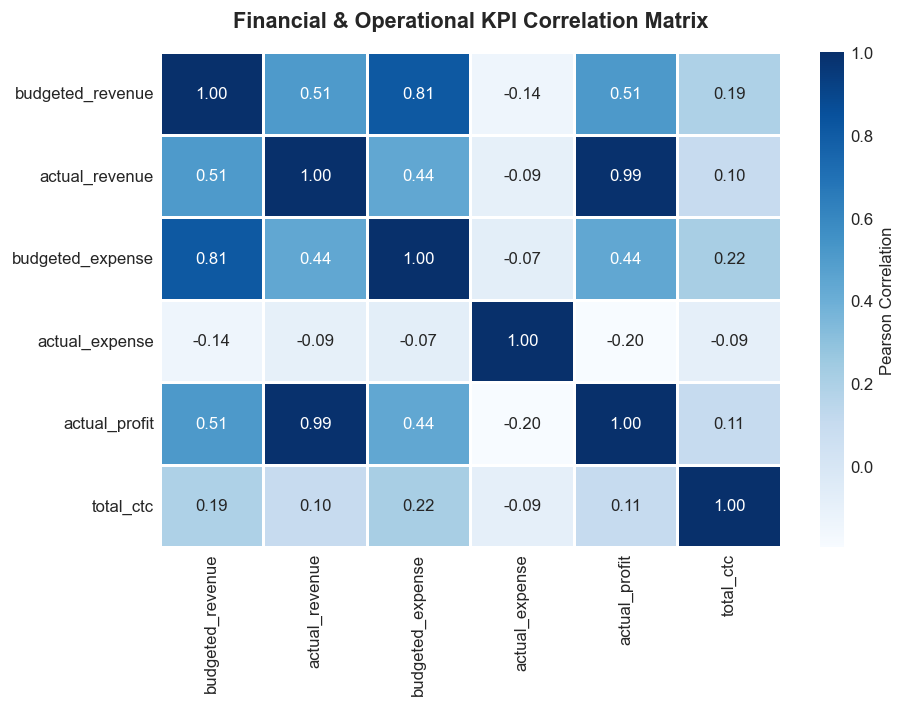

In [136]:
# Correlation Heatmap
# Fix: Convert total_ctc back to numbers if it was formatted as a string
if monthly_bu["total_ctc"].dtype == "object":
    monthly_bu["total_ctc"] = monthly_bu["total_ctc"].str.replace("$", "", regex=False).str.replace("M", "", regex=False).astype(float) * 1e6

# 2. Correlation Matrix
corr_matrix = monthly_bu[[
    "budgeted_revenue",
    "actual_revenue",
    "budgeted_expense",
    "actual_expense",
    "actual_profit",
    "total_ctc",
]].corr()

# 3. Plot Heatmap (Changed color to 'YlGnBu')
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="Blues",  # <-- Changed color scheme here
    fmt=".2f",
    linewidths=0.8,
    cbar_kws={"label": "Pearson Correlation"},
)
plt.title(
    "Financial & Operational KPI Correlation Matrix",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.tight_layout()
plt.savefig("chart14_correlation_heatmap.png")
plt.show()

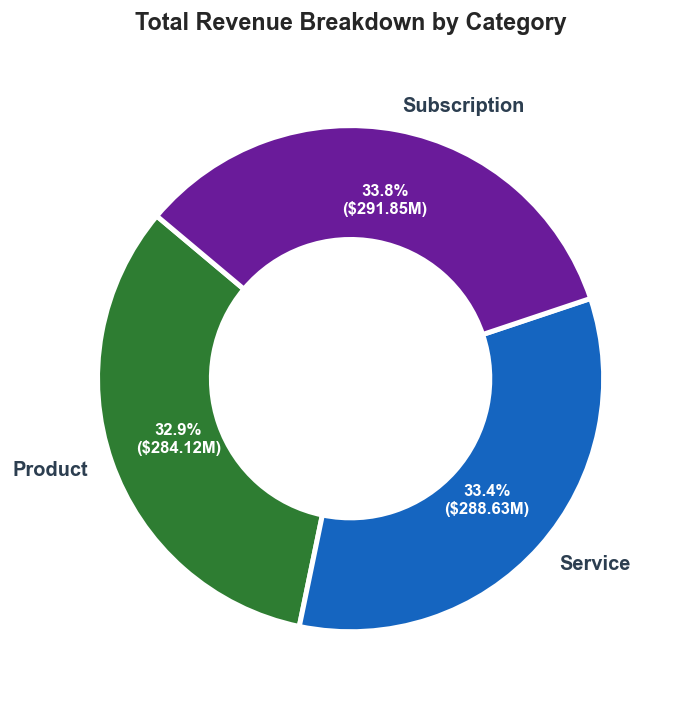

In [159]:
# Total Revenue Breakdown by Category (Donut Chart)

rev_cat = revenue.groupby('category')['amount'].sum().reset_index()
colors_rev = ['#2e7d32', '#1565c0', '#6a1b9a']  # Rich, deep contrast colors

fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    rev_cat['amount'], 
    labels=rev_cat['category'], 
    autopct=lambda pct: f"{pct:.1f}%\n(${pct*rev_cat['amount'].sum()/100/1e6:.2f}M)",
    pctdistance=0.72,  # Perfectly centers values inside the colored ring
    startangle=140, 
    colors=colors_rev,
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=3),
    textprops=dict(fontsize=11, fontweight='bold')
)

plt.setp(autotexts, size=10, weight="bold", color="white")
plt.setp(texts, size=12, weight="bold", color="#2c3e50")
ax.set_title('Total Revenue Breakdown by Category' , fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('fixed_chart5_revenue_donut.png')
plt.show()


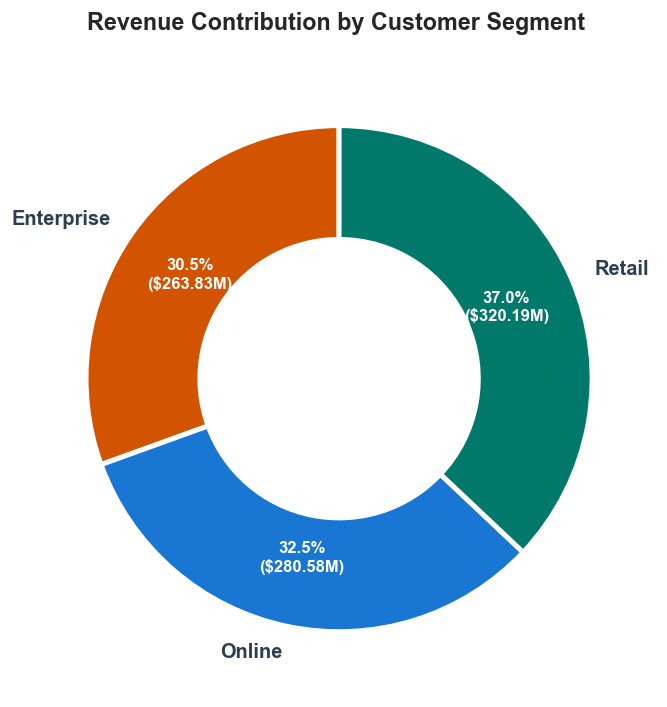

In [160]:
# Revenue Contribution by Customer Segment (Donut Chart)

rev_cust_merged = revenue.merge(df_customers, on='customer_id', how='left')
seg_rev = rev_cust_merged.groupby('segment')['amount'].sum().reset_index()
colors_seg = ['#d35400', '#1976d2', '#00796b']  # High-contrast segment palette

fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    seg_rev['amount'], 
    labels=seg_rev['segment'], 
    autopct=lambda pct: f"{pct:.1f}%\n(${pct*seg_rev['amount'].sum()/100/1e6:.2f}M)",
    pctdistance=0.72,  # Perfectly centers values inside the colored ring
    startangle=90, 
    colors=colors_seg,
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=3),
    textprops=dict(fontsize=11, fontweight='bold')
)

plt.setp(autotexts, size=10, weight="bold", color="white")
plt.setp(texts, size=12, weight="bold", color="#2c3e50")
ax.set_title('Revenue Contribution by Customer Segment ', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('fixed_chart8_segment_donut.png')
plt.show()

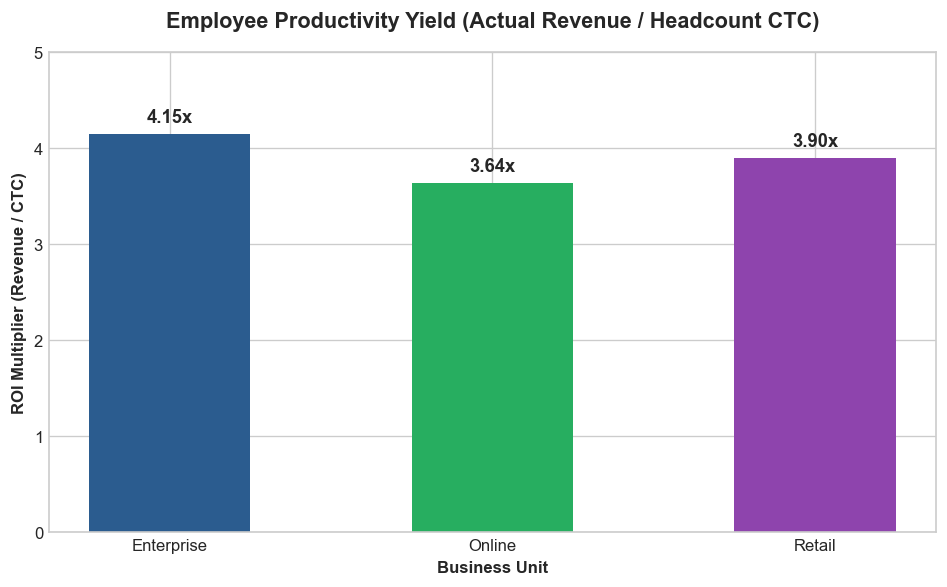

In [144]:
# Employee Productivity ROI Ratio (Bar Chart)
bu_perf_raw = (
    merged_budget.groupby("business_unit")
    .agg({"actual_revenue": "sum", "actual_expense": "sum", "actual_profit": "sum"})
    .reset_index()
)

hc_bu = (
    df_headcount.groupby("business_unit")
    .agg(
        active_employees=("status", lambda x: (x == "Active").sum()),
        total_ctc=("cost_to_company", "sum"),
    )
    .reset_index()
)

prod_summary = bu_perf_raw.merge(hc_bu, on="business_unit")
prod_summary["revenue_ctc_roi"] = (
    prod_summary["actual_revenue"] / prod_summary["total_ctc"]
)

plt.figure(figsize=(8, 5))
bars = plt.bar(
    prod_summary["business_unit"],
    prod_summary["revenue_ctc_roi"],
    color=["#2b5c8f", "#27ae60", "#8e44ad"],
    width=0.5,
)

for bar in bars:
  yval = bar.get_height()
  plt.text(
      bar.get_x() + bar.get_width() / 2.0,
      yval + 0.08,
      f"{yval:.2f}x",
      ha="center",
      va="bottom",
      fontweight="bold",
      fontsize=11,
  )

plt.title(
    "Employee Productivity Yield (Actual Revenue / Headcount CTC)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Business Unit", fontweight="bold")
plt.ylabel("ROI Multiplier (Revenue / CTC)", fontweight="bold")
plt.ylim(0, 5)
plt.tight_layout()
plt.savefig("chart11_productivity_roi.png")
plt.show()


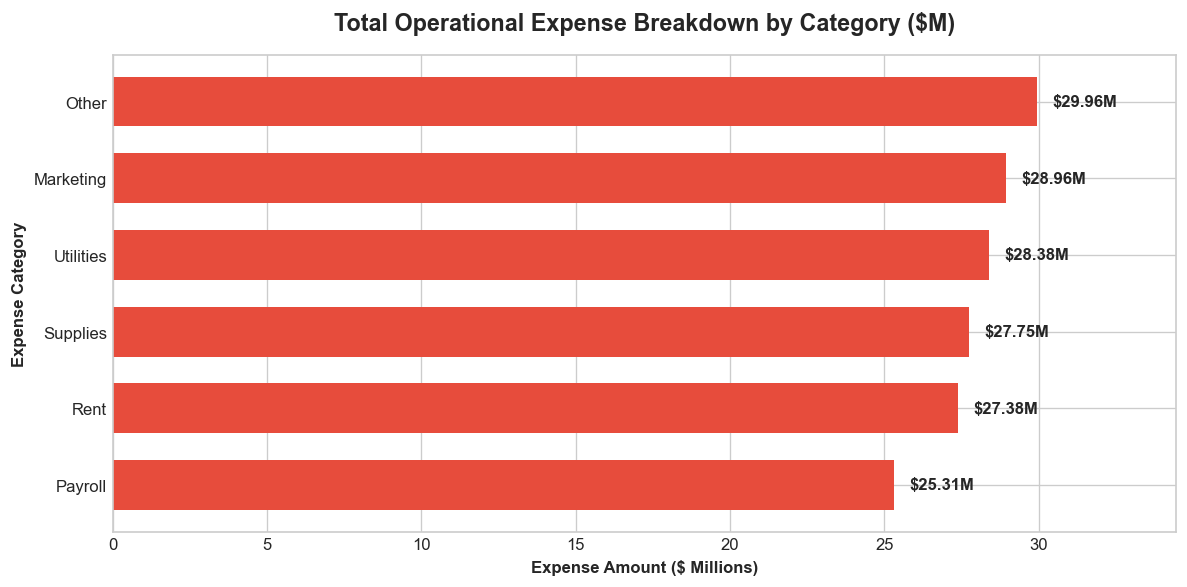

In [165]:
# Expense Breakdown by Category (Horizontal Bar Chart)

exp_cat = (
    expense.groupby("category")["amount_abs"]
    .sum()
    .reset_index()
    .sort_values(by="amount_abs", ascending=True)
)

plt.figure(figsize=(10, 5))
bars = plt.barh(
    exp_cat["category"],
    exp_cat["amount_abs"] / 1e6,
    color="#e74c3c",
    edgecolor="none",
    height=0.65,
)

for bar in bars:
  width = bar.get_width()
  plt.text(
      width + 0.5,
      bar.get_y() + bar.get_height() / 2,
      f"${width:.2f}M",
      ha="left",
      va="center",
      fontweight="bold",
      fontsize=10,
  )

plt.title(
    "Total Operational Expense Breakdown by Category ($M)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Expense Amount ($ Millions)", fontweight="bold")
plt.ylabel("Expense Category", fontweight="bold")
plt.xlim(0, max(exp_cat["amount_abs"] / 1e6) * 1.15)
plt.tight_layout()
plt.savefig("chart6_expense_bars.png")
plt.show()


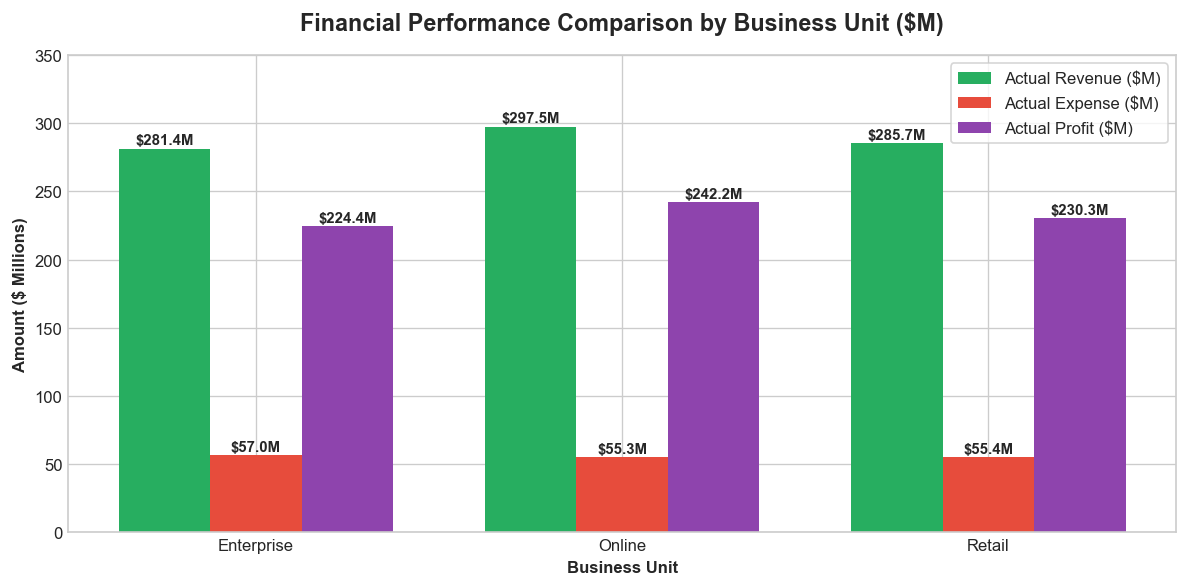

In [146]:
# Chart 7: Business Unit Comparison (Grouped Bar Chart)
# ------------------------------------------------------------------------------
bu_perf_raw = (
    merged_budget.groupby("business_unit")
    .agg({"actual_revenue": "sum", "actual_expense": "sum", "actual_profit": "sum"})
    .reset_index()
)

x = np.arange(len(bu_perf_raw["business_unit"]))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar(
    x - width,
    bu_perf_raw["actual_revenue"] / 1e6,
    width,
    label="Actual Revenue ($M)",
    color="#27ae60",
)
plt.bar(
    x,
    bu_perf_raw["actual_expense"] / 1e6,
    width,
    label="Actual Expense ($M)",
    color="#e74c3c",
)
plt.bar(
    x + width,
    bu_perf_raw["actual_profit"] / 1e6,
    width,
    label="Actual Profit ($M)",
    color="#8e44ad",
)

for i in range(len(x)):
  rev_v = bu_perf_raw["actual_revenue"].iloc[i] / 1e6
  exp_v = bu_perf_raw["actual_expense"].iloc[i] / 1e6
  prof_v = bu_perf_raw["actual_profit"].iloc[i] / 1e6
  plt.text(
      x[i] - width,
      rev_v + 3,
      f"${rev_v:.1f}M",
      ha="center",
      fontsize=9,
      fontweight="bold",
  )
  plt.text(
      x[i], exp_v + 3, f"${exp_v:.1f}M", ha="center", fontsize=9, fontweight="bold"
  )
  plt.text(
      x[i] + width,
      prof_v + 3,
      f"${prof_v:.1f}M",
      ha="center",
      fontsize=9,
      fontweight="bold",
  )

plt.title(
    "Financial Performance Comparison by Business Unit ($M)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Business Unit", fontweight="bold")
plt.ylabel("Amount ($ Millions)", fontweight="bold")
plt.xticks(x, bu_perf_raw["business_unit"])
plt.ylim(0, 350)
plt.legend(frameon=True, facecolor="white")
plt.tight_layout()
plt.savefig("chart7_bu_performance.png")
plt.show()


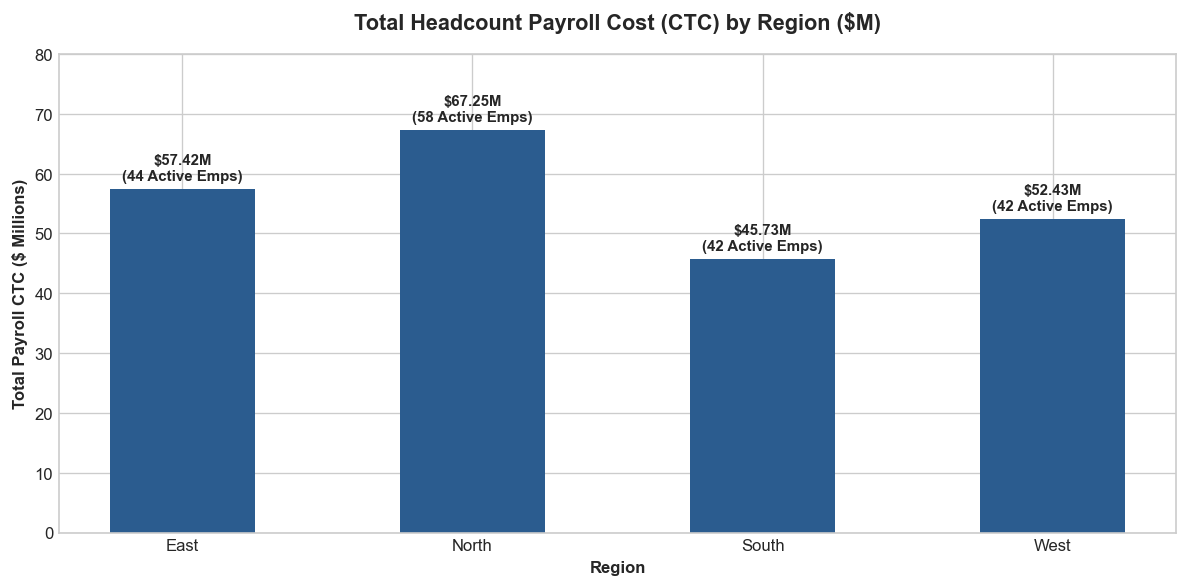

In [148]:
# Chart 16: Regional Headcount Payroll Cost (CTC) (Bar Chart with Annotations)
# ------------------------------------------------------------------------------
hc_reg = df_headcount.groupby('region').agg(
    total_emp=('employee_id', 'count'),
    active_emp=('status', lambda x: (x == 'Active').sum()),
    total_ctc=('cost_to_company', 'sum')
).reset_index()

plt.figure(figsize=(10, 5))
bars = plt.bar(hc_reg['region'], hc_reg['total_ctc']/1e6, color='#2b5c8f', width=0.5)

for i, bar in enumerate(bars):
    yval = bar.get_height()
    emp_cnt = hc_reg['active_emp'].iloc[i]
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f"${yval:.2f}M\n({emp_cnt} Active Emps)", ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.title('Total Headcount Payroll Cost (CTC) by Region ($M)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Region', fontweight='bold')
plt.ylabel('Total Payroll CTC ($ Millions)', fontweight='bold')
plt.ylim(0, 80)
plt.tight_layout()
plt.savefig('chart16_regional_headcount_ctc.png')
plt.show()

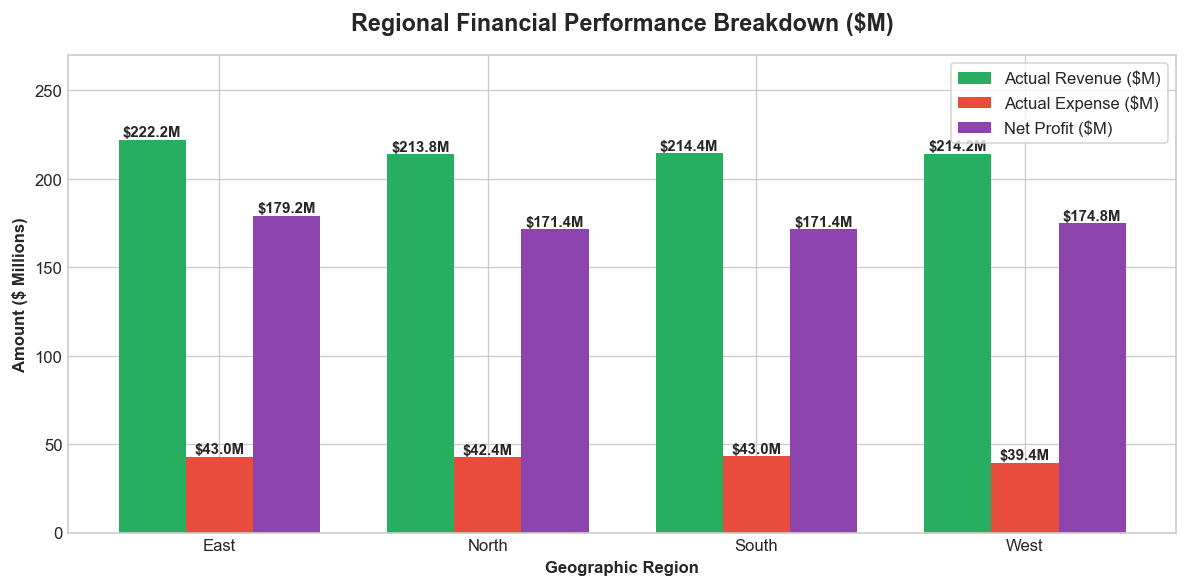

In [150]:
# Chart 15: Regional Financial Breakdown (Grouped Bar Chart)
# ------------------------------------------------------------------------------
reg_perf = df_financial.groupby(['region', 'account_type'])['amount'].sum().unstack().fillna(0)
reg_perf['Expense_Abs'] = reg_perf['Expense'].abs()
reg_perf['Profit'] = reg_perf['Revenue'] - reg_perf['Expense_Abs']
reg_perf = reg_perf.reset_index()

x = np.arange(len(reg_perf['region']))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x - width, reg_perf['Revenue']/1e6, width, label='Actual Revenue ($M)', color='#27ae60')
plt.bar(x, reg_perf['Expense_Abs']/1e6, width, label='Actual Expense ($M)', color='#e74c3c')
plt.bar(x + width, reg_perf['Profit']/1e6, width, label='Net Profit ($M)', color='#8e44ad')

for i in range(len(x)):
    rev_v = reg_perf['Revenue'].iloc[i]/1e6
    exp_v = reg_perf['Expense_Abs'].iloc[i]/1e6
    prof_v = reg_perf['Profit'].iloc[i]/1e6
    plt.text(x[i] - width, rev_v + 2, f"${rev_v:.1f}M", ha='center', fontsize=9, fontweight='bold')
    plt.text(x[i], exp_v + 2, f"${exp_v:.1f}M", ha='center', fontsize=9, fontweight='bold')
    plt.text(x[i] + width, prof_v + 2, f"${prof_v:.1f}M", ha='center', fontsize=9, fontweight='bold')

plt.title('Regional Financial Performance Breakdown ($M)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Geographic Region', fontweight='bold')
plt.ylabel('Amount ($ Millions)', fontweight='bold')
plt.xticks(x, reg_perf['region'])
plt.ylim(0, 270)
plt.legend(frameon=True, facecolor='white')
plt.tight_layout()
plt.savefig('chart15_regional_performance.png')
plt.show()


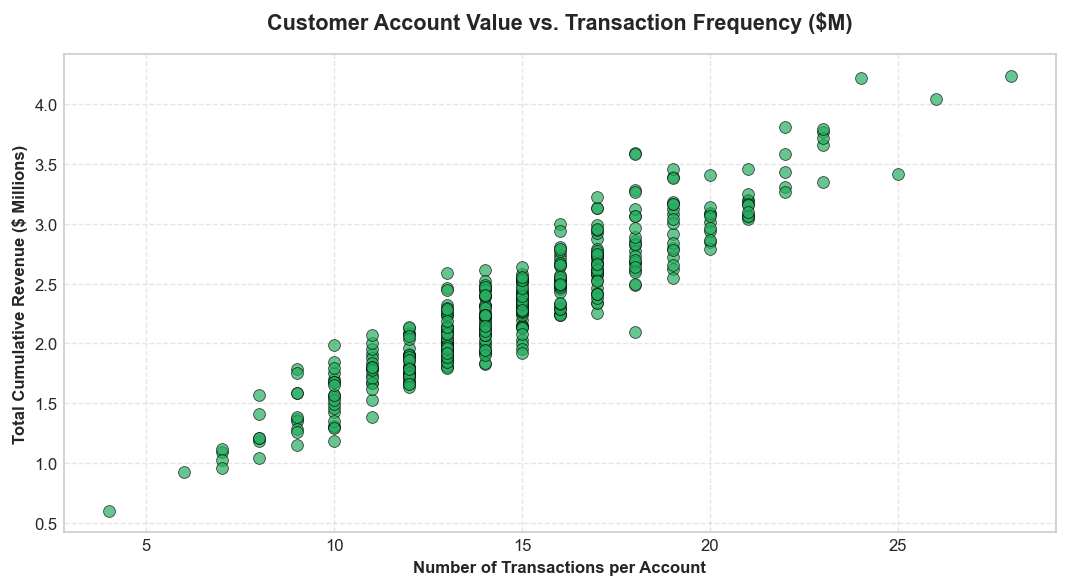

In [149]:
# ------------------------------------------------------------------------------
# Customer Account Value vs. Transaction Frequency (Scatterplot)
# ------------------------------------------------------------------------------
cust_scatter = revenue.groupby('customer_id')['amount'].agg(['sum', 'count']).reset_index()

plt.figure(figsize=(9, 5))
plt.scatter(cust_scatter['count'], cust_scatter['sum']/1e6, color='#27ae60', alpha=0.7, edgecolors='black', linewidths=0.5, s=50)

plt.title('Customer Account Value vs. Transaction Frequency ($M)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Number of Transactions per Account', fontweight='bold')
plt.ylabel('Total Cumulative Revenue ($ Millions)', fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('chart17_customer_scatterplot.png')
plt.show()